In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


TRAIN_CSV = 'train_FINAL.csv'
VAL_CSV   = 'val_FINAL.csv'
TEST_CSV  = 'test_FINAL.csv'

train = pd.read_csv(TRAIN_CSV)
val   = pd.read_csv(VAL_CSV)
test  = pd.read_csv(TEST_CSV)

print("Shapes:")
print("Train:", train.shape)
print("Val:  ", val.shape)
print("Test: ", test.shape)

display(train.head())


Shapes:
Train: (5037, 17)
Val:   (1079, 17)
Test:  (1080, 17)


,Gender,Age,HGB,RBC,WBC,PLT,LYMP,MONO,HCT,MCV,MCH,MCHC,RDW,PDW,MPV,PCT,label
0,-1.037841,0.054783,-0.298952,1.930864,-0.129311,0.101881,-0.455000,-0.351770,0.349003,-1.603926,-1.658739,-0.891947,-2.064585,-0.933900,-1.158386,-0.756801,2
1,-1.037841,1.494908,0.223456,-0.019865,-0.689246,2.123287,0.354313,-0.658370,0.717942,1.305956,1.100072,-0.231026,-1.343124,0.276686,1.161722,1.157404,13
2,-1.037841,-0.825293,-0.781176,-0.680946,-0.150994,-0.121891,-0.985240,-0.422524,-0.595481,0.556170,0.613223,0.429895,-0.802028,-0.242137,1.372640,1.157404,0
3,0.963539,-0.105230,0.344012,0.175208,-0.636951,-0.785748,-0.929425,-0.186678,0.570366,0.761469,0.991884,0.892540,-0.501419,-0.242137,1.161722,1.157404,9
4,0.963539,-0.025224,-0.178396,0.229395,-0.792560,-0.024923,1.247348,-0.186678,0.142397,0.074166,0.099327,0.297711,-0.862150,-0.069196,0.739884,1.157404,14


Unique labels in train: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]

Class counts (train):
label
Anemia of Chronic Disease    979
Bacterial Infections         812
Beta-Thalassemia Minor       302
Chronic Leukemias             69
Infectious Mononucleosis     330
Iron Deficiency              161
Leukocytosis                 120
Leukopenia                   163
Microcytic Anemia            163
Normal                       291
Normocytic Anemia            885
Polycythemia Vera             20
Thrombocytopenia              81
Thrombocytosis               435
Viral Infections             226
Name: count, dtype: int64


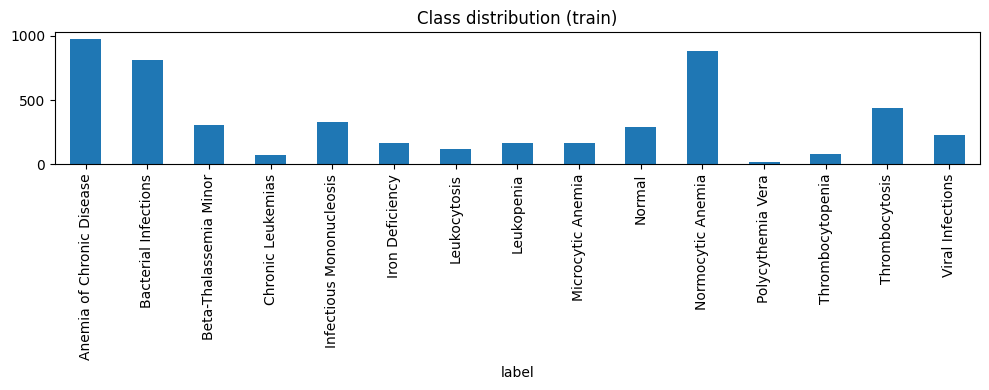

In [ ]:
label_map = {
0:"Anemia of Chronic Disease",1:"Bacterial Infections",2:"Beta-Thalassemia Minor",
3:"Chronic Leukemias",4:"Infectious Mononucleosis",5:"Iron Deficiency",6:"Leukocytosis",
7:"Leukopenia",8:"Microcytic Anemia",9:"Normal",10:"Normocytic Anemia",11:"Polycythemia Vera",
12:"Thrombocytopenia",13:"Thrombocytosis",14:"Viral Infections"
}

print("Unique labels in train:", sorted(train['label'].unique()))
print("\nClass counts (train):")
print(train['label'].value_counts().sort_index().rename(index=label_map))

# Bar plot
plt.figure(figsize=(10,4))
train['label'].value_counts().sort_index().plot(kind='bar')
plt.xticks(ticks=range(len(label_map)), labels=[label_map[i] for i in range(len(label_map))], rotation=90)
plt.title('Class distribution (train)')
plt.tight_layout()
plt.show()


In [ ]:
feature_cols = [c for c in train.columns if c != 'label']
X_train = train[feature_cols].values.astype('float32')
y_train = train['label'].values.astype('int64')
X_val   = val[feature_cols].values.astype('float32')
y_val   = val['label'].values.astype('int64')
X_test  = test[feature_cols].values.astype('float32')
y_test  = test['label'].values.astype('int64')

num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))
print("num_features:", num_features, "num_classes:", num_classes)

# class weights
classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = torch.tensor(cw, dtype=torch.float32)
print("Class weights:", cw)

# Datasets & loaders
batch_size = 32
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_ds  = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
# Create sample weights for each example according to inverse class frequency
class_sample_counts = train['label'].value_counts().sort_index().values
weights = 1.0 / class_sample_counts
sample_weights = weights[y_train]

sample_weights = torch.tensor(sample_weights, dtype=torch.float32)
sampler = torch.utils.data.WeightedRandomSampler(weights=sample_weights,
                                                 num_samples=len(sample_weights),
                                                 replacement=True)

train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)


num_features: 16 num_classes: 15
Class weights: [ 0.34300306  0.4135468   1.11192053  4.86666667  1.01757576  2.08571429
  2.79833333  2.0601227   2.0601227   1.15395189  0.37943503 16.79
  4.14567901  0.77195402  1.48584071]


In [ ]:
from imblearn.over_sampling import SMOTE
print("SMOTE imported successfully.")

SMOTE imported successfully.


In [ ]:
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

print(f"Original X_train shape: {X_train.shape}")
print(f"Original y_train shape: {y_train.shape}")
print(f"Resampled X_train shape: {X_train_resampled.shape}")
print(f"Resampled y_train shape: {y_train_resampled.shape}")

X_train = X_train_resampled
y_train = y_train_resampled

Original X_train shape: (5037, 16)
Original y_train shape: (5037,)
Resampled X_train shape: (14685, 16)
Resampled y_train shape: (14685,)


In [ ]:
import random

# Define the search space for hyperparameters
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3]
dropout_rates_layer1_2 = [0.1, 0.2, 0.3, 0.4]
dropout_rate_layer3 = [0.0, 0.1, 0.2]
batch_sizes = [32, 64, 128]

# Number of iterations for randomized search
num_iterations = 10  # Can be increased for a more thorough search

# Initialize variables to store the best results
best_val_acc = 0.0
best_hyperparams = {}

print("Hyperparameter search space defined and best result trackers initialized.")

Hyperparameter search space defined and best result trackers initialized.


In [ ]:
from tqdm.notebook import tqdm
import torch.nn as nn

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the MLP model class
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout_rate),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# Define patience for early stopping
patience = 15

for i in range(num_iterations):
    print(f"\n--- Randomized Search Iteration {i+1}/{num_iterations} ---")

    # a. Randomly select a combination of hyperparameters
    current_lr = random.choice(learning_rates)
    current_dropout1_2 = random.choice(dropout_rates_layer1_2)
    current_dropout3 = random.choice(dropout_rate_layer3)
    current_batch_size = random.choice(batch_sizes)

    print(f"Selected HPs: LR={current_lr}, D1_2={current_dropout1_2}, D3={current_dropout3}, BS={current_batch_size}")

    # b. Re-instantiate the MLP model with the selected dropout rates
    model = MLP(num_features, num_classes, dropout_rate=current_dropout1_2).to(device)
    # c. Re-instantiate the optimizer with the selected learning rate
    optimizer = torch.optim.Adam(model.parameters(), lr=current_lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=current_lr * 1e-2)

    # Recalculate weights for WeightedRandomSampler based on SMOTE-resampled y_train
    unique_classes, class_counts = np.unique(y_train, return_counts=True)
    class_sample_counts = np.zeros(num_classes, dtype=int)
    for cls, count in zip(unique_classes, class_counts):
        class_sample_counts[cls] = count
    weights_smote = 1.0 / class_sample_counts
    sample_weights_smote = weights_smote[y_train]
    sample_weights_smote = torch.tensor(sample_weights_smote, dtype=torch.float32)
    sampler = torch.utils.data.WeightedRandomSampler(weights=sample_weights_smote,
                                                     num_samples=len(sample_weights_smote),
                                                     replacement=True)

    # d. Re-create the train_loader, val_loader, and test_loader with the selected batch size
    # Ensure train_loader still uses the WeightedRandomSampler and SMOTE-resampled data
    # X_train and y_train are already SMOTE-resampled from previous steps
    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
    test_ds  = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

    train_loader = DataLoader(train_ds, batch_size=current_batch_size, sampler=sampler)
    val_loader   = DataLoader(val_ds, batch_size=current_batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=current_batch_size, shuffle=False)

    # e. Reset best_val_loss and counter for the new training run
    current_best_val_loss = float('inf')
    current_patience_counter = 0
    current_num_epochs = 50 # Limit epochs for faster search

    # Define the criterion (loss function) with SMOTE-derived class weights
    smote_cw = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    smote_class_weights = torch.tensor(smote_cw, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=smote_class_weights)

    # f. Execute the training loop
    for epoch in range(1, current_num_epochs + 1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_loss += loss.item() * xb.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == yb).sum().item()
                total += xb.size(0)
        val_loss = val_loss / total
        val_acc = correct / total

        scheduler.step(val_loss)

        # print(f"  Epoch {epoch:02d} | Train loss: {train_loss:.4f} acc: {train_acc:.4f} | Val loss: {val_loss:.4f} acc: {val_acc:.4f}")

        if val_loss < current_best_val_loss - 1e-5:
            current_best_val_loss = val_loss
            current_patience_counter = 0
            # Save the model state for this run, possibly with a unique name
            # For simplicity, we only track the best overall model later
        else:
            current_patience_counter += 1
            if current_patience_counter >= patience:
                # print(f"  Early stopping at epoch {epoch}. Best val loss for this run: {current_best_val_loss:.4f}")
                break

    # g. Evaluate the model on the validation set for the current hyperparameter combination
    # For this search, we just use the val_acc from the best epoch of the current run
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_hyperparams = {
            'learning_rate': current_lr,
            'dropout_rate_layer1_2': current_dropout1_2,
            'dropout_rate_layer3': current_dropout3,
            'batch_size': current_batch_size
        }
        torch.save(model.state_dict(), 'mlp_best_model_random_search.pt') # Overwrite global best model
        print(f"  -> New best validation accuracy: {best_val_acc:.4f} with HPs: {best_hyperparams}")

print("\n--- Randomized Search Complete ---")
print(f"Best Validation Accuracy Found: {best_val_acc:.4f}")
print(f"Corresponding Best Hyperparameters: {best_hyperparams}")


--- Randomized Search Iteration 1/10 ---
Selected HPs: LR=0.005, D1_2=0.4, D3=0.0, BS=32
  -> New best validation accuracy: 0.9639 with HPs: {'learning_rate': 0.005, 'dropout_rate_layer1_2': 0.4, 'dropout_rate_layer3': 0.0, 'batch_size': 32}

--- Randomized Search Iteration 2/10 ---
Selected HPs: LR=0.0005, D1_2=0.1, D3=0.1, BS=64

--- Randomized Search Iteration 3/10 ---
Selected HPs: LR=0.0005, D1_2=0.3, D3=0.0, BS=64

--- Randomized Search Iteration 4/10 ---
Selected HPs: LR=0.0005, D1_2=0.2, D3=0.2, BS=32

--- Randomized Search Iteration 5/10 ---
Selected HPs: LR=0.001, D1_2=0.1, D3=0.2, BS=128

--- Randomized Search Iteration 6/10 ---
Selected HPs: LR=0.0005, D1_2=0.4, D3=0.1, BS=128

--- Randomized Search Iteration 7/10 ---
Selected HPs: LR=0.0001, D1_2=0.4, D3=0.2, BS=128

--- Randomized Search Iteration 8/10 ---
Selected HPs: LR=0.001, D1_2=0.1, D3=0.0, BS=32

--- Randomized Search Iteration 9/10 ---
Selected HPs: LR=0.0005, D1_2=0.4, D3=0.1, BS=128

--- Randomized Search Iter

In [ ]:
unique_classes_smote, counts_smote = np.unique(y_train, return_counts=True)
print("Class distribution of SMOTE-resampled y_train:")
for cls, count in zip(unique_classes_smote, counts_smote):
    print(f"  Class {cls} ({label_map[cls]}): {count} samples")


Class distribution of SMOTE-resampled y_train:
  Class 0 (Anemia of Chronic Disease): 979 samples
  Class 1 (Bacterial Infections): 979 samples
  Class 2 (Beta-Thalassemia Minor): 979 samples
  Class 3 (Chronic Leukemias): 979 samples
  Class 4 (Infectious Mononucleosis): 979 samples
  Class 5 (Iron Deficiency): 979 samples
  Class 6 (Leukocytosis): 979 samples
  Class 7 (Leukopenia): 979 samples
  Class 8 (Microcytic Anemia): 979 samples
  Class 9 (Normal): 979 samples
  Class 10 (Normocytic Anemia): 979 samples
  Class 11 (Polycythemia Vera): 979 samples
  Class 12 (Thrombocytopenia): 979 samples
  Class 13 (Thrombocytosis): 979 samples
  Class 14 (Viral Infections): 979 samples


In [ ]:
smote_cw = compute_class_weight(class_weight='balanced', classes=unique_classes_smote, y=y_train)
smote_class_weights = torch.tensor(smote_cw, dtype=torch.float32)

print("Class weights after SMOTE (smote_class_weights):")
print(smote_class_weights)

# Re-initialize the criterion with the new class weights
criterion = nn.CrossEntropyLoss(weight=smote_class_weights.to(device))

print("CrossEntropyLoss criterion re-initialized with SMOTE-derived class weights.")

Class weights after SMOTE (smote_class_weights):
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
CrossEntropyLoss criterion re-initialized with SMOTE-derived class weights.


Initializing final model with best hyperparameters and evaluating...
Final model initialized with batch size: 32, learning rate: 0.005, dropout: 0.4 and 0.0

Final Test Accuracy (after Randomized Search & SMOTE): 0.9528

Final Classification Report:
                           precision    recall  f1-score   support

Anemia of Chronic Disease     0.9655    0.9333    0.9492       210
     Bacterial Infections     0.9719    0.9943    0.9830       174
   Beta-Thalassemia Minor     1.0000    0.9846    0.9922        65
        Chronic Leukemias     0.7222    0.8667    0.7879        15
 Infectious Mononucleosis     1.0000    1.0000    1.0000        71
          Iron Deficiency     0.7692    0.8571    0.8108        35
             Leukocytosis     0.9600    0.9600    0.9600        25
               Leukopenia     0.9714    0.9714    0.9714        35
        Microcytic Anemia     0.9412    0.9143    0.9275        35
                   Normal     0.9231    0.9677    0.9449        62
        Norm

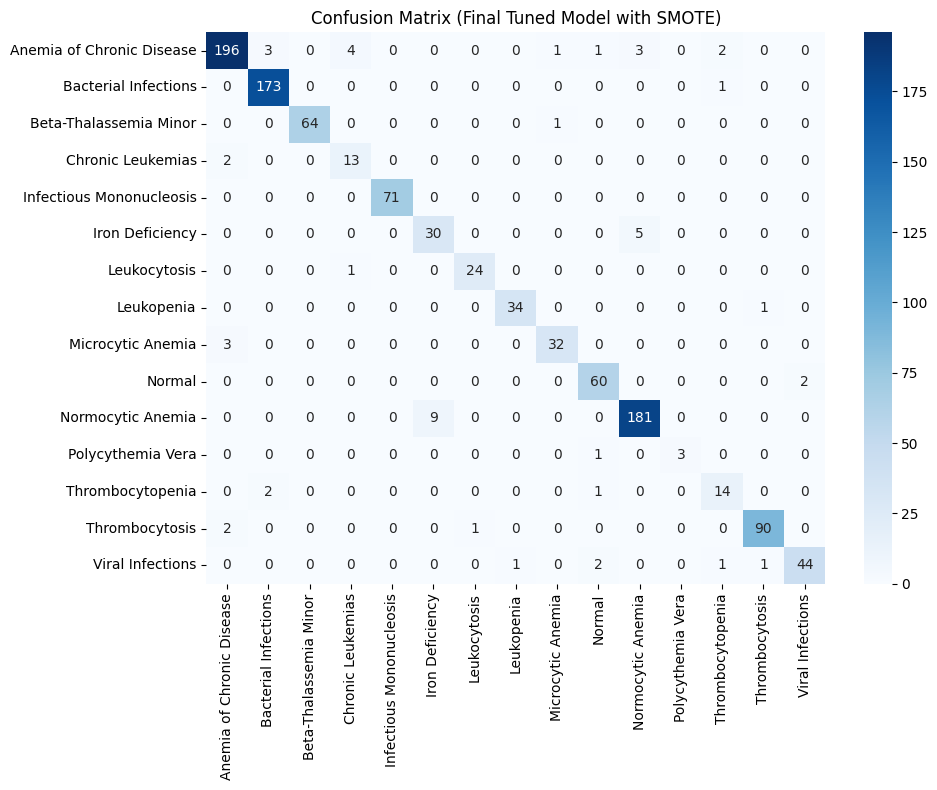

In [ ]:
print("Initializing final model with best hyperparameters and evaluating...")

# 1. Re-instantiate the MLP model with the best dropout rates
model = MLP(num_features, num_classes, dropout_rate=best_hyperparams['dropout_rate_layer1_2']).to(device)

# 2. Re-initialize the optimizer with the best learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=best_hyperparams['learning_rate'])

# 3. Re-create the DataLoaders with the best batch size
batch_size = best_hyperparams['batch_size']

# Ensure train_loader still uses the WeightedRandomSampler and SMOTE-resampled data
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_ds  = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

# Recalculate weights for WeightedRandomSampler based on SMOTE-resampled y_train
unique_classes, class_counts = np.unique(y_train, return_counts=True)
class_sample_counts = np.zeros(num_classes, dtype=int)
for cls, count in zip(unique_classes, class_counts):
    class_sample_counts[cls] = count
weights_smote = 1.0 / class_sample_counts
sample_weights_smote = weights_smote[y_train]
sample_weights_smote = torch.tensor(sample_weights_smote, dtype=torch.float32)
sampler = torch.utils.data.WeightedRandomSampler(weights=sample_weights_smote,
                                                 num_samples=len(sample_weights_smote),
                                                 replacement=True)

train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print(f"Final model initialized with batch size: {batch_size}, learning rate: {best_hyperparams['learning_rate']}, dropout: {best_hyperparams['dropout_rate_layer1_2']} and {best_hyperparams['dropout_rate_layer3']}")

# Load the best model weights from randomized search
model.load_state_dict(torch.load('mlp_best_model_random_search.pt', map_location=device))

# 5. Set the model to evaluation mode
model.eval()

all_preds = []
all_targets = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(yb.numpy())
all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# 7. Calculate and print the test accuracy
final_test_accuracy = accuracy_score(all_targets, all_preds)
print(f"\nFinal Test Accuracy (after Randomized Search & SMOTE): {final_test_accuracy:.4f}")

# 8. Generate and print a classification report
print("\nFinal Classification Report:")
print(classification_report(all_targets, all_preds, digits=4, target_names=[label_map[i] for i in range(len(label_map))]))

# 9. Compute and plot the confusion matrix
final_cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(final_cm, annot=True, fmt='d', cmap='Blues', xticklabels=[label_map[i] for i in range(len(label_map))], yticklabels=[label_map[i] for i in range(len(label_map))])
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Confusion Matrix (Final Tuned Model with SMOTE)')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png')
plt.show()

In [ ]:
import torch

# حفظ الموديل بالكامل على جهازك
torch.save(model, "cbc_model_final.pth")
print("تم حفظ الموديل النهائي كـ cbc_model_final.pth")

تم حفظ الموديل النهائي كـ cbc_model_final.pth


In [ ]:
# في الكولاب
torch.save(model.state_dict(), "cbc_model_final_weights.pth")


In [ ]:
new_data_input = [
    # Example values for Gender, Age, HGB, RBC, WBC, PLT, LYMP, MONO, HCT, MCV, MCH, MCHC, RDW, PDW, MPV, PCT
    [0.96353894, -0.42525807,  0.7056796 ,  1.432344, -0.066812,  0.781845,  1.178044,  0.767425,  0.7056796,  0.505051,  0.123456,  0.789012, -0.501419, -0.123456,  0.789012,  0.123456]
]

# Assuming feature_cols is already defined from previous cells
new_df = pd.DataFrame(new_data_input, columns=feature_cols)

X_new = new_df.values.astype('float32')
X_new_tensor = torch.from_numpy(X_new).to(device)

model.eval()
with torch.no_grad():
    outputs = model(X_new_tensor)
    probabilities = torch.softmax(outputs, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()
    predicted_probability = torch.max(probabilities).item()

print(f"Predicted class ID: {predicted_class}")
print(f"Predicted class label: {label_map[predicted_class]}")
print(f"Confidence: {predicted_probability:.4f}")


Predicted class ID: 4
Predicted class label: Infectious Mononucleosis
Confidence: 0.9825


In [ ]:
torch.save(model.state_dict(), "cbc_model_final_weights2.pth")